# Titanic EDA — Week 1 Day 3

**Dataset:** Titanic passenger data (891 rows, 12 columns)
**Goal:** Explore survival patterns by gender, class, and age group

**Key findings:**
- Females survived at ~74% vs males at ~19%
- First class survived most (~63%)
- Children (0-18) survived at highest rate among age groups

**Cleaning done:**
- Filled Age nulls with median
- Filled Embarked nulls with mode
- Dropped Cabin column (77% missing)

## Key Findings from Titanic EDA

1. **Gender:** Females survived at a much higher rate than males (~74% vs ~19%).
   Likely due to the "women and children first" evacuation policy.

2. **Class:** First class passengers survived most (~63%), followed by second (~47%),
   then third (~24%). Higher class = better access to lifeboats.

3. **Age:** Children (0-18) survived at the highest rate among age groups.
   Again consistent with "women and children first" policy.

In [1]:
import pandas as pd

In [2]:
Titanic_dataset = pd.read_csv('Titanic-Dataset.csv')
pd.set_option("display.max_rows", 5)

In [3]:
Titanic_dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
...,...,...,...,...,...,...,...,...,...,...,...,...
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [4]:
Titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Titanic_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
Titanic_dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.0,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
...,...,...,...,...,...,...,...
75%,668.5,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.0,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
Titanic_dataset.isnull().sum()

PassengerId      0
Survived         0
              ... 
Cabin          687
Embarked         2
Length: 12, dtype: int64

In [8]:
print(Titanic_dataset.groupby('Sex')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [9]:
print(Titanic_dataset.groupby('Pclass')['Survived'].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [10]:
Titanic_dataset['AgeGroup'] = pd.cut(Titanic_dataset['Age'], bins=[0,18,40,100], labels=['0-18','18-40','40+'])
print(Titanic_dataset.groupby('AgeGroup')['Survived'].mean())

AgeGroup
0-18     0.503597
18-40    0.388235
40+      0.366667
Name: Survived, dtype: float64


C:\Users\Kavya\AppData\Local\Temp\ipykernel_20724\3257357332.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(Titanic_dataset.groupby('AgeGroup')['Survived'].mean())


In [11]:
import matplotlib.pyplot as plt

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


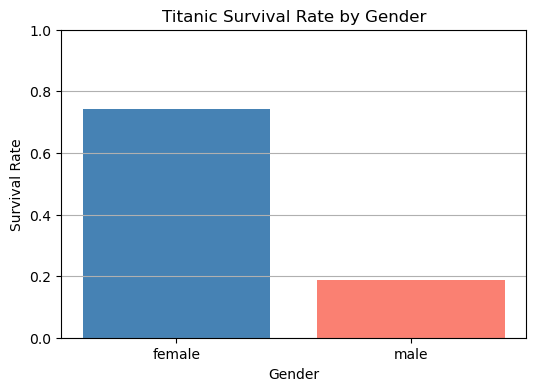

In [12]:
# calculate survival rate per gender first
survival_rate = Titanic_dataset.groupby('Sex')['Survived'].mean()

print(survival_rate)   # check what it looks like before plotting

plt.figure(figsize=(6, 4))
plt.bar(survival_rate.index, survival_rate.values, color=['steelblue', 'salmon'])
plt.title('Titanic Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)       # survival rate is between 0 and 1
plt.grid(True, axis='y')   # grid on y axis only — looks cleaner
plt.savefig('titanic_survival.png', dpi=150, bbox_inches='tight')  # before show
plt.show()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


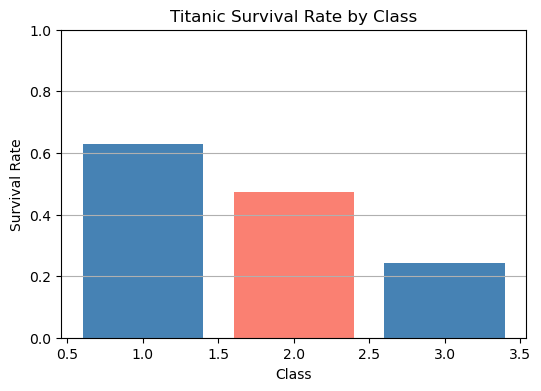

In [13]:
# calculate survival rate per class first
survival_rate = Titanic_dataset.groupby('Pclass')['Survived'].mean()

print(survival_rate)   # check what it looks like before plotting

plt.figure(figsize=(6, 4))
plt.bar(survival_rate.index, survival_rate.values, color=['steelblue', 'salmon'])
plt.title('Titanic Survival Rate by Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)       # survival rate is between 0 and 1
plt.grid(True, axis='y')   # grid on y axis only — looks cleaner
plt.savefig('titanic_survival.png', dpi=150, bbox_inches='tight')  # before show
plt.show()

C:\Users\Kavya\AppData\Local\Temp\ipykernel_20724\1945292720.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = Titanic_dataset.groupby('AgeGroup')['Survived'].mean()


AgeGroup
0-18     0.503597
18-40    0.388235
40+      0.366667
Name: Survived, dtype: float64


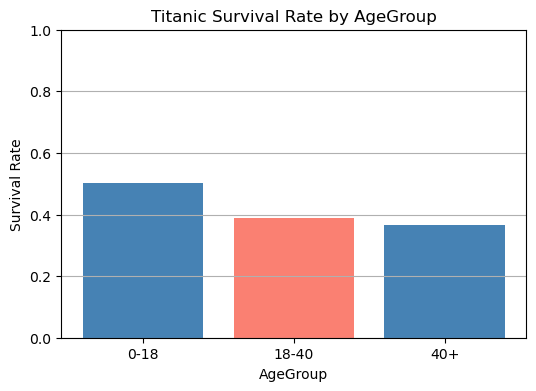

In [14]:
# calculate survival rate per AgeGroup first
Titanic_dataset['AgeGroup'] = pd.cut(Titanic_dataset['Age'], bins=[0,18,40,100], labels=['0-18','18-40','40+'])
survival_rate = Titanic_dataset.groupby('AgeGroup')['Survived'].mean()

print(survival_rate)   # check what it looks like before plotting

plt.figure(figsize=(6, 4))
plt.bar(survival_rate.index, survival_rate.values, color=['steelblue', 'salmon'])
plt.title('Titanic Survival Rate by AgeGroup')
plt.xlabel('AgeGroup')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)       # survival rate is between 0 and 1
plt.grid(True, axis='y')   # grid on y axis only — looks cleaner
plt.savefig('titanic_survival.png', dpi=150, bbox_inches='tight')  # before show
plt.show()

C:\Users\Kavya\AppData\Local\Temp\ipykernel_20724\3963850458.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age = Titanic_dataset.groupby('AgeGroup')['Survived'].mean()


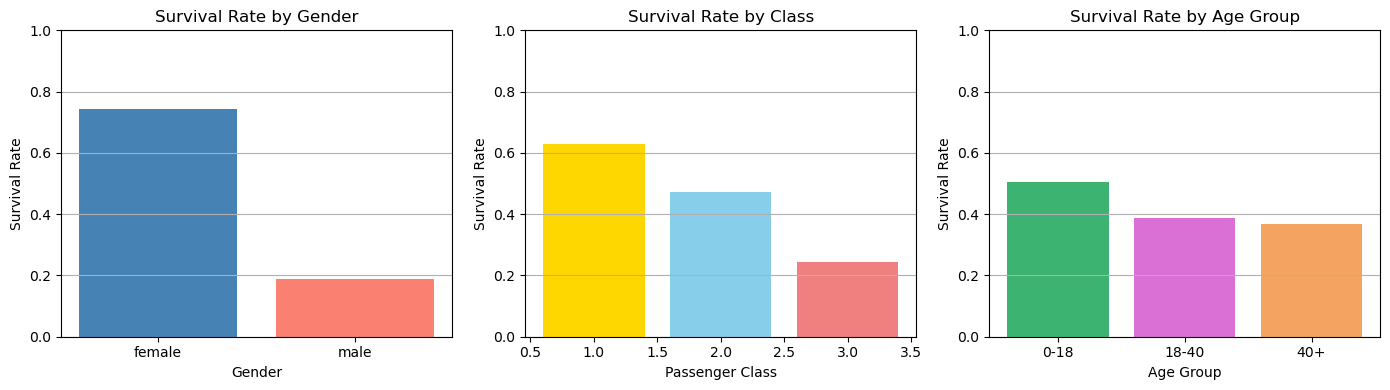

In [15]:
import matplotlib.pyplot as plt

# ── 1. Survival rate by Gender ──────────────────────────────
survival_gender = Titanic_dataset.groupby('Sex')['Survived'].mean()

# ── 2. Survival rate by Class ───────────────────────────────
survival_class = Titanic_dataset.groupby('Pclass')['Survived'].mean()

# ── 3. Survival rate by Age Group ───────────────────────────
Titanic_dataset['AgeGroup'] = pd.cut(
    Titanic_dataset['Age'],
    bins=[0, 18, 40, 100],
    labels=['0-18', '18-40', '40+']
)
survival_age = Titanic_dataset.groupby('AgeGroup')['Survived'].mean()

# ── Plot all 3 side by side ──────────────────────────────────
plt.figure(figsize=(14, 4))

# Chart 1 — Gender
plt.subplot(1, 3, 1)
plt.bar(survival_gender.index, survival_gender.values,
        color=['steelblue', 'salmon'])
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.grid(True, axis='y')

# Chart 2 — Class
plt.subplot(1, 3, 2)
plt.bar(survival_class.index, survival_class.values,
        color=['gold', 'skyblue', 'lightcoral'])
plt.title('Survival Rate by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.grid(True, axis='y')

# Chart 3 — Age Group
plt.subplot(1, 3, 3)
plt.bar(survival_age.index, survival_age.values,
        color=['mediumseagreen', 'orchid', 'sandybrown'])
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.grid(True, axis='y')

plt.tight_layout()
plt.savefig('titanic_survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Step 1 — fill Age with median FIRST
Titanic_dataset['Age'] = Titanic_dataset['Age'].fillna(Titanic_dataset['Age'].median())

Titanic_dataset['AgeGroup'] = pd.cut(
    Titanic_dataset['Age'],
    bins=[0, 18, 40, 100],
    labels=['0-18', '18-40', '40+']
)

# Step 2 — fill Embarked with mode SECOND
Titanic_dataset['Embarked'] = Titanic_dataset['Embarked'].fillna(Titanic_dataset['Embarked'].mode()[0])

# Step 3 — drop Cabin column specifically LAST
Titanic_dataset = Titanic_dataset.drop(columns=['Cabin'])

# Step 4 — verify
print(Titanic_dataset.isnull().sum())

PassengerId    0
Survived       0
              ..
Embarked       0
AgeGroup       0
Length: 12, dtype: int64
